In [4]:
# %%
from __future__ import print_function

import numpy as np 
import matplotlib.pyplot as plt
import openpathsampling as paths
import os
# we use the %run magic because this isn't in a package
import torch 
import aimmd 
import sys
import aimmdTIS
from aimmdTIS import potential_0, TIS_AIMMD_setup, read_config
import openpathsampling.engines.toy as toys
from functools import reduce


In [5]:
import openpathsampling.engines.toy as toys
settings = {"n_harmonics": 20,
            "rotation_degrees": 0,
            "scale": 2}
pes = aimmdTIS.potential_switch("FacePotential", settings)
n_harmonics = pes.n_harmonics


123
pot dimensions without oscillators: 2
harmonic oscillators omegas:
array([0.        , 0.        , 1.        , 1.5       , 7.57175348,
       4.28911468, 3.81481163, 6.41051815, 7.75575176, 5.38485168,
       9.84611359, 7.47863791, 5.84745521, 5.13694015, 4.74542413,
       7.83239766, 5.50857796, 2.47742317, 5.18435404, 7.90396325,
       3.45993384, 3.40361405])


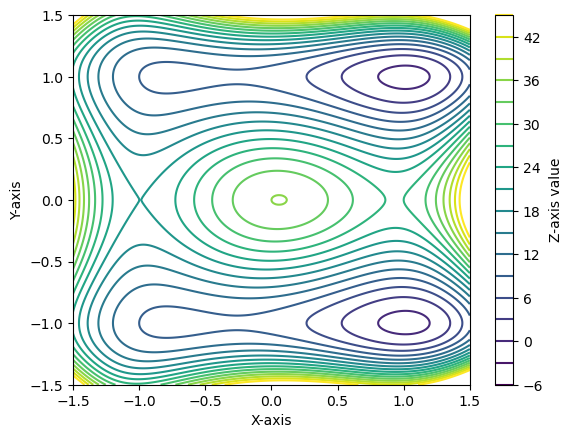

In [6]:
x = np.linspace(pes.extent[0],pes.extent[1],300)
y = np.linspace(pes.extent[2],pes.extent[3],300)
x_2d, y_2d, U = pes.plot_2d_pes(x,y)

# Step 2: Create the colormap
colormap = 'plasma'  # You can choose a different colormap from Matplotlib's colormaps

# Step 3: Generate the 2D image

plt.figure()
plt.contour(x_2d,y_2d,U, levels = 3*pes.levels)
plt.colorbar(label='Z-axis value')  # Add a colorbar to show the intensity scale
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [7]:

integ = toys.LangevinBAOABIntegrator(dt=0.02, temperature=1, gamma=10)
options={
    'integ' : integ,
    'n_frames_max' : 5000,
    'n_steps_per_frame' : 1
}
toy_eng = toys.Engine(
    options=options,
    topology=pes.topology
)
toy_eng.initialized = True

template = pes.template(toy_eng)
toy_eng.current_snapshot = template
paths.PathMover.engine = toy_eng

# Collective variables to define the states
opA = paths.CoordinateFunctionCV(name="opA", f=pes.stable_interface_function, center=pes.state_A)
opB = paths.CoordinateFunctionCV(name="opB", f=pes.stable_interface_function, center=pes.state_B)

# State volumes in CV space
stateA = paths.CVDefinedVolume(opA, 0.0, pes.state_boundary).named('StateA')
stateB = paths.CVDefinedVolume(opB, 0.0, pes.state_boundary).named('StateB')
#

In [8]:
# Fake an initial trajectory
init_AB = paths.Trajectory(pes.simple_initial_path(1000,toy_eng))
state_sampled = "A"
if state_sampled == "A":
    initial_snapshot = init_AB.snapshots[0]
    check = stateA(initial_snapshot)
    print("start in A: {}".format(check))
elif state_sampled == "B":
    initial_snapshot = init_AB.snapshots[-1]
    check = stateB(initial_snapshot)
    print("start in B: {}".format(check))

start in A: True


In [9]:
# %%
storage = paths.Storage("stable_{}_store.nc".format(state_sampled), "w", template=template)
storage.save(toy_eng)
storage.tag['template'] = initial_snapshot
storage.snapshots[0] = initial_snapshot

In [10]:
# %%

tps_network = paths.TPSNetwork(stateA, stateB)

states = set(tps_network.initial_states +
  tps_network.final_states)


In [11]:
sim = paths.DirectSimulation(
    storage=storage,
    engine=toy_eng,
    states=states,
    initial_snapshot=storage.snapshots[0]
)


In [12]:
n_run = 10000
sim.run(n_run)

In [13]:
descriptor_transform = paths.FunctionCV('descriptor_transform', lambda s: s.coordinates[0], cv_wrap_numpy_array=True).with_diskcache()


In [14]:
traj = storage.trajectories[-1]
descriptor = descriptor_transform(traj)
weights_traj = np.ones((np.shape(descriptor)[0]))
print(np.shape(descriptor))
H_interface, xedges, yedges = np.histogram2d(descriptor[:,0],
                                                descriptor[:,1],
                                                bins=(x, y), 
                                                weights = weights_traj)

(10001, 22)


In [15]:
sum_check_A = 0
sum_check_B =0
for i in range(len(traj)):

    check_A= stateA(traj.get_as_proxy(i))
    check_B= stateB(traj.get_as_proxy(i))

    if check_A:
        sum_check_A +=1
    if check_B:
        sum_check_B +=1

print("Percentage in A: {}".format(sum_check_A/len(traj)))
print("Percentage in B: {}".format(sum_check_B/len(traj)))


Percentage in A: 0.5284471552844715
Percentage in B: 0.0


/var/folders/v_/71cb78555216g7fdd79cc29c0000gn/T/ipykernel_8221/2751504962.py:10: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(H_interface_normalized.T), origin='lower',interpolation='nearest',
/var/folders/v_/71cb78555216g7fdd79cc29c0000gn/T/ipykernel_8221/2751504962.py:14: UserWarning: The following kwargs were not used by contour: 'c'
  plt.contour(x_2d,y_2d,states_plot, c="Blue")


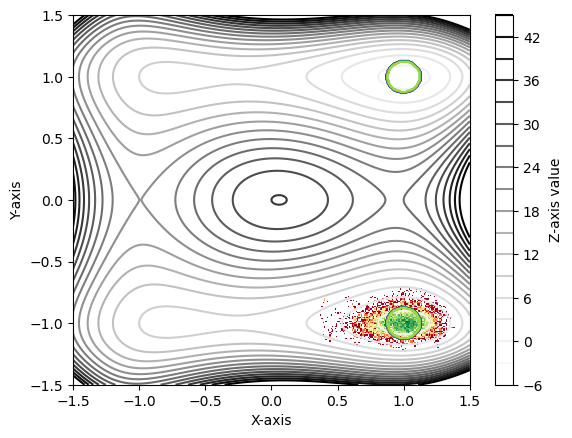

In [18]:
plt.figure()
plt.contour(x_2d,y_2d,U, 3*pes.levels,cmap='Greys')
plt.colorbar(label='Z-axis value') 
repcolordict = {0 : 'k-', 1 : 'r-', 2 : 'g-', 3 : 'b-', 4 : 'r-'}
states_plot = np.vectorize(aimmdTIS.CallableVolume(stateA))(x_2d, -y_2d)
states_plot += np.vectorize(aimmdTIS.CallableVolume(stateB))(x_2d, -y_2d)

H_interface_normalized = H_interface/(np.sum(H_interface)*(x[1]-x[0])*(y[1]-y[0]))

plt.imshow(np.log(H_interface_normalized.T), origin='lower',interpolation='nearest', 
                       extent=pes.extent,aspect="auto", cmap="RdYlGn")

 # Add a colorbar to show the intensity scale
plt.contour(x_2d,y_2d,states_plot, c="Blue")
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [19]:
storage.close()